In [1]:
# Import necessary libraries
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings

In [2]:
# load diabetes dataset
diabetes_data = pd.read_csv('/home/jovyan/work/midtermaters/Homework 4/PimaIndiansDiabetes.csv')
ddf = diabetes_data.copy() #ddf - new copy of og dataframe
# print the data types of each column in ddf
ddf.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [3]:
ddf

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
663,9,145,80,46,130,37.9,0.637,40,1
664,6,115,60,39,0,33.7,0.245,40,1
665,1,112,80,45,132,34.8,0.217,24,0
666,4,145,82,18,0,32.5,0.235,70,1


In [4]:
ddf['Outcome'] = ddf['Outcome'].astype('category')
#converting outcome column in dataframe to the categorical data type

In [5]:
ddf.dtypes
#return the dtypes in the dataframe; returns series with data type from each column

Pregnancies                    int64
Glucose                        int64
BloodPressure                  int64
SkinThickness                  int64
Insulin                        int64
BMI                          float64
DiabetesPedigreeFunction     float64
Age                            int64
Outcome                     category
dtype: object

Q1: Pregnancies, Glucose, BloodPressure, SkinThickness, BMI, DiabetesPedigreeFunction, and Age are numeric variables, which contain data that allow for arithmetic comparisons and manipulations because these features represent measured or calculated quantities. The Outcome is considered a categorical variable because its' binary scale represents distinct groups or categories; in doing so, this variable serves a more descriptive role as it is neither measured or calculated, only observed.

Q2: Use appropriate graphs to predict which of the variables (on their own) are most helpful in predicting the outcome? 
•	For each variable draw an appropriate graph (boxplot for numerical values and barplot for categorical values). Explain your answer. 

In [6]:
#subset the dataframe to convert categorical text columns to numerical dummy vars
#one-hot encoding creates binary columns for each category in each column
ddf_encoded = pd.get_dummies(ddf, columns=['Outcome'], drop_first=True)
#drop_first=True in pandas drops one redundant column e.g., keeps only Feb-Dec to avoid multicollinearity
ddf_encoded

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome_1
0,6,148,72,35,0,33.6,0.627,50,True
1,1,85,66,29,0,26.6,0.351,31,False
2,8,183,64,0,0,23.3,0.672,32,True
3,1,89,66,23,94,28.1,0.167,21,False
4,0,137,40,35,168,43.1,2.288,33,True
...,...,...,...,...,...,...,...,...,...
663,9,145,80,46,130,37.9,0.637,40,True
664,6,115,60,39,0,33.7,0.245,40,True
665,1,112,80,45,132,34.8,0.217,24,False
666,4,145,82,18,0,32.5,0.235,70,True


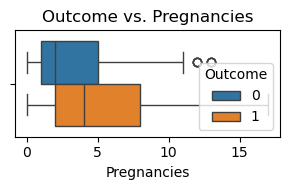

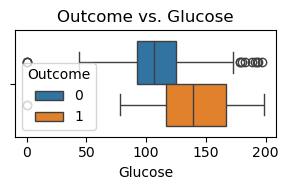

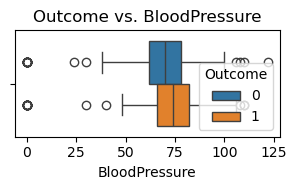

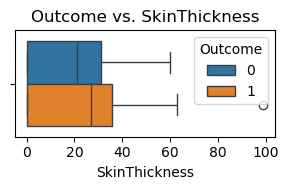

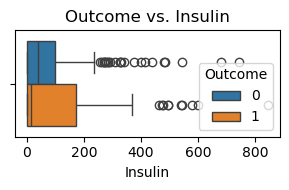

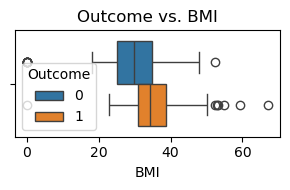

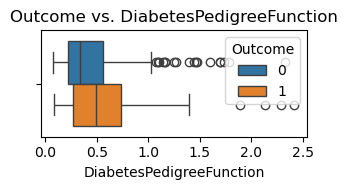

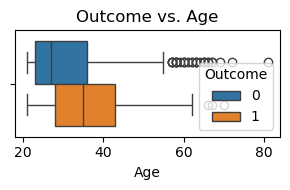

In [7]:
# Step 2: Visualize the relationship between predictors and response

# supress warnings
warnings.simplefilter('ignore')

y_var = 'Outcome' 
features = [col for col in ddf.columns if col != y_var]

for i in features: #loop over features
    plt.figure(figsize=(3, 2))
    sns.boxplot(x=i, hue=y_var, data=ddf)
    plt.title(f'{y_var} vs. {i}')
    plt.tight_layout()
    plt.show()


Q2: The variable most helpful in predicting the outcome is Glucose, which we can tell because the distributions of non-diabetics and diabetics have the least overlap (IQRs show minimal overlap). Other honorable mentions were BMI and Age, as the boxes overlap only partially; one median is captured in the other's IQR, but not both, indicating its variable's capacity to serve as a moderate univariate predictor.

Q3: Are there any missing values? and how do we fix this?
•	Notice that some of the values are missing and replaced with 0. For example a blood pressure of 0 doesn’t make sense and it can have an impact on the models. So how do we identify which 0 represents the value 0 and which represents NA? Explain your answer. 

Q3: Yes, there are missing values in the dataset. Because zeros are inputted as valid values and placeholders for missing data, its difficult to distinguish which 0 represents the value 0 and which represents NA. To identify missing values, we need domain knowledge to select the biologically implausible values. Zero values are valid for only certain variables in the dataset; for example, its reasonable for an individual to have zero pregnancies, but its physiologically impossible for a living individual to have a value of 0 for any of the following variables: Glucose, BloodPressure, SkinThickness, Insulin, or BMI.

Then, we subset those columns of the dataframe and replace the placeholder zeros with actual NA's. Using SimpleImputer, we estimate values for the placeholders from the remaining numeric data in each column. The missing values coded as NaN are filled with imputed values. This method of handling zeros allows our models to learn from as many biologically meaningful points in the dataset, which is why this approach was preferred over other strategies(ie, dropping rows with multiple missing values).

In [8]:
#import revelant libraries
import math
import statistics
import pickle
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV

In [9]:
ddfsub = ddf_encoded[["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]]
ddfsub


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
663,9,145,80,46,130,37.9,0.637,40
664,6,115,60,39,0,33.7,0.245,40
665,1,112,80,45,132,34.8,0.217,24
666,4,145,82,18,0,32.5,0.235,70


In [10]:
print(ddfsub.describe(include='all')) # summary stats
print(ddfsub.nunique()) # display how many distinct values per column
print("Zeros per column:\n", (ddfsub == 0).sum()) # count # of zeros per column

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   668.000000  668.000000     668.000000     668.000000  668.000000   
mean      3.812874  120.405689      68.748503      20.567365   79.654192   
std       3.365672   32.291473      19.526392      16.020600  115.827750   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      64.000000       0.000000    0.000000   
50%       3.000000  116.000000      72.000000      23.000000   36.500000   
75%       6.000000  140.000000      80.000000      32.000000  126.000000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age  
count  668.000000                668.000000  668.000000  
mean    31.860180                  0.477329   33.091317  
std      7.827111                  0.341398   11.711386  
min      0.000000                  0.078000   21.000000  
25%     27.100000        

In [11]:
# supress warnings
warnings.simplefilter('ignore')

# 0) If ddfsub was itself a slice of another df, make it a copy to avoid SettingWithCopyWarning:
ddfsub2 = ddfsub.copy()

# 1) Define “invalid zero” columns
zero_missing = [
    "Glucose",          # cannot have 0 mg/dL
    "BloodPressure",    # cannot have  0 mm Hg
    "SkinThickness",    # cannot have  0 mm skin fold
    "Insulin",          # cannot have  0 μU/ml
    "BMI"               # cannot have  0 kg/m²
]

# 2) Convert placeholder zeros to NaN
ddfsub2.loc[:, zero_missing] = ddfsub2.loc[:, zero_missing].replace(0, np.nan)

# 3) Set Simpleimputer to replace NaN values with imputed values using column's median
imp = SimpleImputer(missing_values=np.nan, strategy='median')

# 4) Compute median for selected columns with missing values & transform -
# return array with imputed values
X = ddfsub2[zero_missing]
X_imputed = imp.fit_transform(X)

# 5) Assign the imputed values back into ddfsub
ddfsub2.loc[:, zero_missing] = X_imputed

In [12]:
# send imputer as pickle
pickle.dump(imp, open("SimpleImputer.pkl", "wb"))

In [13]:
from sklearn.preprocessing import MinMaxScaler

In [14]:
min_max_scaler = MinMaxScaler() #initialize scalar
mostly_complete_minmax = min_max_scaler.fit_transform(ddfsub2)
#fit scalar to data imputed dataframe; compute min-max of each column and apply transformation
mostly_complete_minmax #display

array([[0.35294118, 0.67096774, 0.48979592, ..., 0.31492843, 0.23441503,
        0.48333333],
       [0.05882353, 0.26451613, 0.42857143, ..., 0.17177914, 0.11656704,
        0.16666667],
       [0.47058824, 0.89677419, 0.40816327, ..., 0.10429448, 0.25362938,
        0.18333333],
       ...,
       [0.05882353, 0.43870968, 0.57142857, ..., 0.3394683 , 0.05935098,
        0.05      ],
       [0.23529412, 0.6516129 , 0.59183673, ..., 0.29243354, 0.06703672,
        0.81666667],
       [0.58823529, 0.43225806, 0.46938776, ..., 0.19018405, 0.02690009,
        0.31666667]])

In [15]:
min_max_scaler.scale_
# min_max_scaler.min_
# send scaler as pickle
pickle.dump(min_max_scaler, open("min_max_scaler.pkl", "wb"))

In [16]:
#importing necessary libraries and modules
from sklearn.ensemble import RandomForestClassifier

I tuned the hyperparameters and trained all models on the full dataset. To explain my approach, I first selected models covered in class, then considered more recently introduced methods such as kNN and neural nets. Initially, I evaluated the models used in our homework assignments, including linear and logistic regression—linear regression was eliminated because it assumes a continuous outcome, and logistic regression seemed inappropriate because it performs poorly at capturing non-linear decision boundaries. Since SVM and Random Forest both achieved a ROC AUC of approximately 0.97 on the cancer dataset in Homework 4, I ran those two models first. Next, I considered kNN and neural nets: neural nets were ruled out due to their high computational cost on a relatively small dataset. Because kNN is suitable for smaller samples, I included it, but it ultimately performed the worst among the three models. Overall, SVM and Random Forest produced similar ROC AUC scores that were higher than kNN.

In [17]:
# testing the randforest

In [18]:
X = mostly_complete_minmax #select normalized features from df to store as X 
y = ddf["Outcome"] #save one hot data as y
print(X)

[[0.35294118 0.67096774 0.48979592 ... 0.31492843 0.23441503 0.48333333]
 [0.05882353 0.26451613 0.42857143 ... 0.17177914 0.11656704 0.16666667]
 [0.47058824 0.89677419 0.40816327 ... 0.10429448 0.25362938 0.18333333]
 ...
 [0.05882353 0.43870968 0.57142857 ... 0.3394683  0.05935098 0.05      ]
 [0.23529412 0.6516129  0.59183673 ... 0.29243354 0.06703672 0.81666667]
 [0.58823529 0.43225806 0.46938776 ... 0.19018405 0.02690009 0.31666667]]


In [19]:
# supress warnings
warnings.simplefilter('ignore')
#initializing an empty dictionary to store each feature's ROC_AUC_score
feature_results = {} #initialize a dictionary to store auc scores with respective "i" after each loop
# defining hyperparameters; range of values for max_features and max_depth
parameters = {'max_features':range(1, 8), 'max_depth': range(3, 7)}
rfc = RandomForestClassifier(random_state=42) # initialize randforest
rfcp = GridSearchCV(rfc, parameters, scoring='roc_auc') # wrap & tune hyperparameters
rfcp.fit(X, y) #fit to entire dataset
print("Best params:", rfcp.best_params_) #print best hyperparameters
print("Best AUC:", rfcp.best_score_) #print best auc score

Best params: {'max_depth': 4, 'max_features': 2}
Best AUC: 0.841250566689576


In [20]:
#new randforest with selected hyperparameters
brfc_model = RandomForestClassifier(max_features = 4, max_depth = 2, random_state=42)
brfc_model.fit(X, y) #fitting randforest model; best rfc
feature_results["best model test"] = [roc_auc_score(y, brfc_model.predict_proba(X)[:,1])]
#adding another entry to the feature results dict to add roc score for display purposes
feature_results #display updated dictionary

{'best model test': [0.8620761389640108]}

In [21]:
#pickle for the best model
pickle.dump(brfc_model, open("brfc_model.pkl", "wb"))

In [22]:
# testing SVM model

In [23]:
# import necessary modules
from sklearn.svm import SVC
from sklearn import svm, datasets

In [24]:
# supress warnings
warnings.simplefilter('ignore')
#provide list of kernels we want to test
#linear = assumes data is linearly separable in current space
#poly - applies polynomial transformation to handle non-linear relationships
#rbf - applies radial basis function kernel that maps data into higher-dimensional space for non-linear separability
parameters = {'kernel':('linear', 'poly', 'rbf'), 'C':[1, 10]}
svc = svm.SVC(random_state=42) #initial svm model
clf = GridSearchCV(svc, parameters, scoring='roc_auc', n_jobs=-1) #wrap & tune hyperparameters
clf.fit(X, y) #fitting svm model
print("Best params:", clf.best_params_) #display best parameters 
print("Best AUC:", clf.best_score_) #display best score

Best params: {'C': 10, 'kernel': 'linear'}
Best AUC: 0.8380127755271299


In [25]:
#intialize svm with best hyperparameters
svm_model = SVC(C=10, kernel='linear', probability = True, random_state=42)
svm_model.fit(X, y) #fit SVM on full dataset
# [:,1] extracts probability of the positive class; compute roc auc
SVM_feature_results = roc_auc_score(y, svm_model.predict_proba(X)[:,1])
SVM_feature_results #display

0.8433237243305893

###third test kNN -- not necessary to grade or consider that much below; did kNN for a sanity check

In [26]:
from sklearn.neighbors import KNeighborsClassifier

In [27]:
parameters = {'n_neighbors': [3, 5, 7, 9], 'weights':['uniform', 'distance']} 
# uniform: equal vote; distance: weighted by inverse distance
knn = KNeighborsClassifier() #initial knn model
knf = GridSearchCV(knn, parameters, scoring='roc_auc', cv=5, n_jobs=-1)
knf.fit(X, y.values.ravel())
print("Best kNN params:", knf.best_params_)
print("Best kNN AUC:", knf.best_score_)

Best kNN params: {'n_neighbors': 9, 'weights': 'distance'}
Best kNN AUC: 0.8221419995998133
